<a href="https://colab.research.google.com/github/MengOonLee/Deep_learning/blob/master/Experiments/Probabilistic/Distributions/Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Distributions

## Coding Tutorials
#### 1. [Univariate Distributions](#univariate_distributions)
#### 2. [Multivariate Distributions](#multivariate_distributions)
#### 3. [The Independent Distribution](#the_independent_distribution)
#### 4. [Sampling and log probs](#sampling_and_log_probs)
#### 5. [Trainable Distributions](#trainable_distributions)

In [ ]:
%%bash
pip install --no-cache-dir -qU pip
pip install --no-cache-dir -qU \
    numpy pandas matplotlib seaborn \
    scikit-learn torch

***
## Univariate distributions
<a id='univariate_distributions'></a>

In [ ]:
import torch
torch.manual_seed(seed=42)

loc = torch.tensor(data=0, dtype=torch.float32)
scale = torch.tensor(data=1, dtype=torch.float32)
normal = torch.distributions.Normal(loc=loc, scale=scale)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

samples = normal.sample(sample_shape=(3,))
print("Samples shape:", samples.shape)

log_prob = normal.log_prob(value=samples)
print("Prob shape:", torch.exp(log_prob).shape)

Batch shape: torch.Size([])
Event shape: torch.Size([])
Samples shape: torch.Size([3])
Prob shape: torch.Size([3])


In [ ]:
import torch
torch.manual_seed(seed=42)

probs = torch.tensor(data=[0.4, 0.6], dtype=torch.float32)
bernoulli = torch.distributions.Bernoulli(probs=probs)
print("Batch shape:", bernoulli.batch_shape)
print("Event shape:", bernoulli.event_shape)

samples = bernoulli.sample(sample_shape=(3,))
print("Samples shape:", samples.shape)

log_prob = bernoulli.log_prob(value=samples)
print("Prob shape:", torch.exp(log_prob).shape)

Batch shape: torch.Size([2])
Event shape: torch.Size([])
Samples shape: torch.Size([3, 2])
Prob shape: torch.Size([3, 2])


In [1]:
# Create a normal distribution from Tensorflow Distributions
import torch
torch.manual_seed(seed=42)

loc = torch.tensor(data=0, dtype=torch.float32)
scale = torch.tensor(data=1, dtype=torch.float32)
normal = torch.distributions.Normal(loc=loc, scale=scale)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

# Sample from the chosen distribution...
normal.sample()

Batch shape: torch.Size([])
Event shape: torch.Size([])


tensor(0.3367)

In [2]:
# ... or sample multiple times
samples = normal.sample(sample_shape=(7,))
print("Samples shape:", samples.shape)

Samples shape: torch.Size([7])


In [3]:
# Obtain value of probability's density
import torch
torch.manual_seed(seed=42)

prob = torch.exp(normal.log_prob(value=samples))
print("Prob shape:", prob.shape)

Prob shape: torch.Size([7])


In [4]:
# Obtain value of log probability
import torch
torch.manual_seed(seed=42)

value = torch.tensor(data=0, dtype=torch.float32)
torch.exp(normal.log_prob(value=value))

tensor(0.3989)

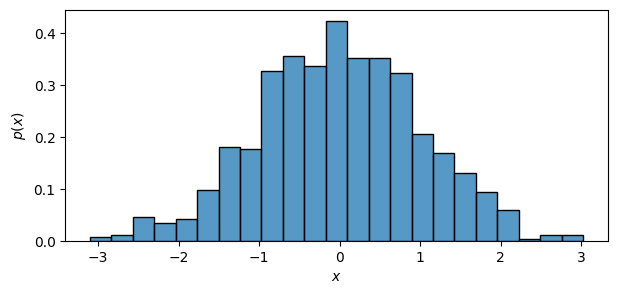

In [5]:
# Plot a histogram, approximating the density
import matplotlib.pyplot as plt
import seaborn as sns

plt_samples = normal.sample(sample_shape=(1000,))
plt.figure(figsize=(7, 3))
sns.histplot(x=plt_samples, stat="density")
plt.xlabel(xlabel=r"$x$")
plt.ylabel(ylabel=r"$p(x)$")
plt.show()

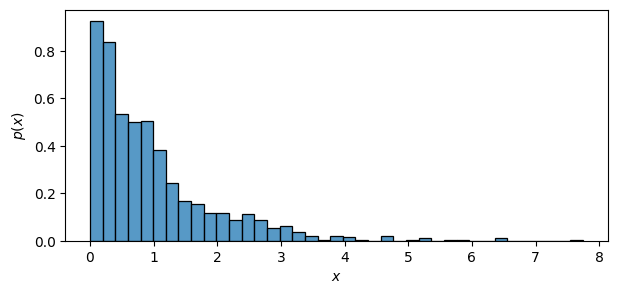

In [6]:
# Do the same for the exponential distribution
import torch
torch.manual_seed(seed=42)
import matplotlib.pyplot as plt

rate = torch.tensor(data=1, dtype=torch.float32)
exponential = torch.distributions.Exponential(rate=rate)

plt_samples = exponential.sample(sample_shape=(1000,))
plt.figure(figsize=(7, 3))
sns.histplot(x=plt_samples, stat="density")
plt.xlabel(xlabel=r"$x$")
plt.ylabel(ylabel=r"$p(x)$")
plt.show()

In [ ]:
# Sample as before
exponential.sample(sample_shape=(7,)).shape

torch.Size([7])

Batch shape: torch.Size([])
Event shape: torch.Size([])


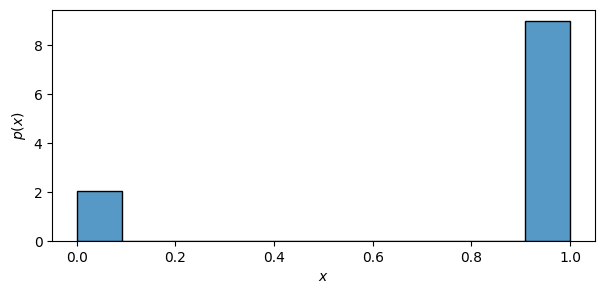

In [7]:
# Create a Bernoulli distribution (discrete)
import torch
torch.manual_seed(seed=42)

probs = torch.tensor(data=0.8, dtype=torch.float32)
bernoulli = torch.distributions.Bernoulli(probs=probs,
    validate_args=False)
print("Batch shape:", bernoulli.batch_shape)
print("Event shape:", bernoulli.event_shape)

plt_samples = bernoulli.sample(sample_shape=(1000,))
plt.figure(figsize=(7, 3))
sns.histplot(x=plt_samples, stat="density")
plt.xlabel(xlabel=r"$x$")
plt.ylabel(ylabel=r"$p(x)$")
plt.show()

#### A word of caution on discrete distributions

In [ ]:
# Calculate Bernoulli prob and see that 0.5 and -1
# do not give the correct probability!
import torch
torch.manual_seed(seed=42)

for k in [0, 0.5, 1, -1]:
    value = torch.tensor(data=k, dtype=torch.float32)
    prob = torch.exp(bernoulli.log_prob(value=value))
    print('prob result %.2f for k = %.1f'%(prob, k))

prob result 0.20 for k = 0.0
prob result 0.40 for k = 0.5
prob result 0.80 for k = 1.0
prob result 0.05 for k = -1.0


In [ ]:
# Replicate the scores to see what is occurring under the hood
import numpy as np
np.random.seed(seed=42)

def my_bernoulli(p_success, k):
    k = np.array(k, dtype=np.float32)
    return np.power(p_success, k)*np.power((1 - p_success), (1 - k))

In [ ]:
# Evaluate it as before
for k in [0, 0.5, 1, -1]:
    prob = my_bernoulli(p_success=0.8, k=k)
    print('prob result %.2f for k = %.1f'%(prob, k))

prob result 0.20 for k = 0.0
prob result 0.40 for k = 0.5
prob result 0.80 for k = 1.0
prob result 0.05 for k = -1.0


#### Work with batch distributions

In [ ]:
# Create a batched Bernoulli distribution
import torch
torch.manual_seed(seed=42)

probs = torch.tensor(data=[0.1, 0.25, 0.5, 0.75, 0.9],
    dtype=torch.float32)
bernoulli = torch.distributions.Bernoulli(probs=probs)
print("Batch shape:", bernoulli.batch_shape)
print("Event shape:", bernoulli.event_shape)

Batch shape: torch.Size([5])
Event shape: torch.Size([])


In [ ]:
# Sample from it, noting the shape
bernoulli.sample(sample_shape=(4,)).shape

torch.Size([4, 5])

In [ ]:
# Use a batch shape with higher rank
import torch
torch.manual_seed(seed=42)

probs = torch.tensor(data=[
    [0.5, 0.5],
    [0.8, 0.2],
    [0.25, 0.75]
], dtype=torch.float32)
bernoulli = torch.distributions.Bernoulli(probs=probs)
print("Batch shape:", bernoulli.batch_shape)
print("Event shape:", bernoulli.event_shape)

Batch shape: torch.Size([3, 2])
Event shape: torch.Size([])


In [ ]:
# Sample from this batch of distributions
bernoulli.sample(sample_shape=(2,)).shape

torch.Size([2, 3, 2])

In [ ]:
# Determine probabilities from this batch distribution
import torch
torch.manual_seed(seed=42)

samples = torch.tensor(data=[
    [1, 0],
    [0, 0],
    [1, 1]
], dtype=torch.float32)
torch.exp(bernoulli.log_prob(value=samples)).shape

torch.Size([3, 2])

***
<a id='multivariate_distributions'></a>
## Multivariate Distributions


In [ ]:
import torch
torch.manual_seed(seed=42)

loc = torch.tensor(data=[-1, 0.5], dtype=torch.float32)
scale_diag = torch.tensor(data=[1, 1.5], dtype=torch.float32)
sigma = torch.diag(input=scale_diag**2)
scale_tril = torch.linalg.cholesky(input=sigma)
print("Scale tril shape:", scale_tril.shape)

normal = torch.distributions.MultivariateNormal(
    loc=loc, scale_tril=scale_tril)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

samples = normal.sample(sample_shape=(3,))
print("Samples shape:", samples.shape)

prob = torch.exp(normal.log_prob(value=samples))
print("Prob shape:", prob.shape)

Scale tril shape: torch.Size([2, 2])
Batch shape: torch.Size([])
Event shape: torch.Size([2])
Samples shape: torch.Size([3, 2])
Prob shape: torch.Size([3])


In [ ]:
import torch
torch.manual_seed(seed=42)

loc = torch.tensor(data=[-1, 0.5], dtype=torch.float32)
scale = torch.tensor(data=[1, 1.5], dtype=torch.float32)
normal = torch.distributions.Normal(loc=loc, scale=scale)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

samples = normal.sample(sample_shape=(3,))
print("Samples shape:", samples.shape)

prob = torch.exp(normal.log_prob(value=samples))
print("Prob shape:", prob.shape)

Batch shape: torch.Size([2])
Event shape: torch.Size([])
Samples shape: torch.Size([3, 2])
Prob shape: torch.Size([3, 2])


In [ ]:
import torch
torch.manual_seed(seed=42)

loc = torch.tensor(data=[
    [-1, 0.5],
    [2, 0],
    [-0.5, 1.5]
], dtype=torch.float32)
scale_diag = torch.tensor(data=[
    [1, 1.5],
    [2, 0.5],
    [1, 1]
], dtype=torch.float32)
sigma = torch.diag_embed(input=scale_diag**2)
scale_tril = torch.linalg.cholesky(input=sigma)
print("Scale tril shape:", scale_tril.shape)

normal = torch.distributions.MultivariateNormal(
    loc=loc, scale_tril=scale_tril)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

samples = normal.sample(sample_shape=(2,))
print("Samples shape:", samples.shape)

prob = torch.exp(normal.log_prob(value=samples))
print("Prob shape:", prob.shape)

Scale tril shape: torch.Size([3, 2, 2])
Batch shape: torch.Size([3])
Event shape: torch.Size([2])
Samples shape: torch.Size([2, 3, 2])
Prob shape: torch.Size([2, 3])


#### Basic multivariate distributions

In [8]:
# Define 2D multivariate Gaussian with diagonal covariance matrix
import torch
torch.manual_seed(seed=42)

loc = torch.tensor(data=[0, 1], dtype=torch.float32)
scale_diag = torch.tensor(data=[1, 2], dtype=torch.float32)
sigma = torch.diag(input=scale_diag**2)
scale_tril = torch.linalg.cholesky(input=sigma)
print("Scale tril shape:", scale_tril.shape)

normal = torch.distributions.MultivariateNormal(
    loc=loc, scale_tril=scale_tril)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

# Sample from it
samples = normal.sample(sample_shape=(3,))
print("Samples shape:", samples.shape)

prob = torch.exp(normal.log_prob(value=samples))
print("Prob shape:", prob.shape)

Scale tril shape: torch.Size([2, 2])
Batch shape: torch.Size([])
Event shape: torch.Size([2])
Samples shape: torch.Size([3, 2])
Prob shape: torch.Size([3])


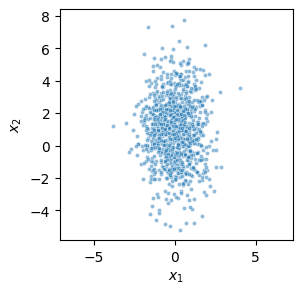

In [9]:
# Make a plot
import matplotlib.pyplot as plt
import seaborn as sns

plt_samples = normal.sample(sample_shape=(1000,))
plt.figure(figsize=(3, 3))
sns.scatterplot(x=plt_samples[:, 0], y=plt_samples[:, 1],
    marker=".", alpha=.5)
plt.xlabel(xlabel=r"$x_1$")
plt.ylabel(ylabel=r"$x_2$")
plt.axis("equal")
plt.show()

Scale tril shape: torch.Size([2, 2])
Batch shape: torch.Size([])
Event shape: torch.Size([2])


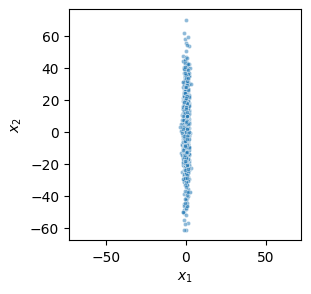

In [10]:
import torch
torch.manual_seed(seed=42)
import matplotlib.pyplot as plt
import seaborn as sns

loc = torch.tensor(data=[0, 1], dtype=torch.float32)
scale_diag = torch.tensor(data=[1, 20], dtype=torch.float32)
sigma = torch.diag(input=scale_diag**2)
scale_tril = torch.linalg.cholesky(input=sigma)
print("Scale tril shape:", scale_tril.shape)

normal = torch.distributions.MultivariateNormal(
    loc=loc, scale_tril=scale_tril)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

plt_samples = normal.sample(sample_shape=(1000,))
plt.figure(figsize=(3, 3))
sns.scatterplot(x=plt_samples[:, 0], y=plt_samples[:, 1],
    marker=".", alpha=.5)
plt.xlabel(xlabel=r"$x_1$")
plt.ylabel(ylabel=r"$x_2$")
plt.axis("equal")
plt.show()

#### Batches of multivariate distributions

In [1]:
# Create three "batches" of multivariate normals
import torch
torch.manual_seed(seed=42)

loc = torch.tensor(data=[0, 0], dtype=torch.float32)
scale_diag = torch.tensor(data=[
    [1, 2],
    [2, 1],
    [2, 2]
], dtype=torch.float32)
sigma = torch.diag_embed(input=scale_diag**2)
scale_tril = torch.linalg.cholesky(input=sigma)
print("Scale tril shape:", scale_tril.shape)

normal = torch.distributions.MultivariateNormal(
    loc=loc, scale_tril=scale_tril)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

# Sample from it
samples = normal.sample(sample_shape=(2,))
print("Samples shape:", samples.shape)

# Compute log probs
prob = torch.exp(normal.log_prob(value=samples))
print("Prob shape:", prob.shape)

Scale tril shape: torch.Size([3, 2, 2])
Batch shape: torch.Size([3])
Event shape: torch.Size([2])
Samples shape: torch.Size([2, 3, 2])
Prob shape: torch.Size([2, 3])


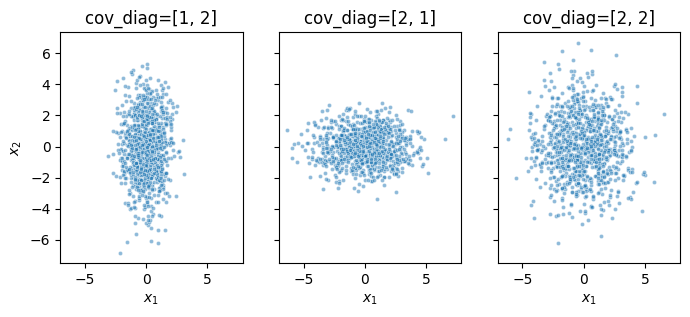

In [3]:
# Plot samples from the batched multivariate Gaussian
import matplotlib.pyplot as plt
import seaborn as sns

# Create a sample for a plot -- notice the shape
plt_samples = normal.sample(sample_shape=(1000,))

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 3),
    sharex=True, sharey=True)
titles = ["cov_diag=[1, 2]", "cov_diag=[2, 1]", "cov_diag=[2, 2]"]
axs[0].set_ylabel(ylabel=r"$x_2$")

for i, (ax, title) in enumerate(zip(axs, titles)):
    # take the ith batch [samples x event_shape]
    samples = plt_samples[:, i, :]
    sns.scatterplot(ax=ax, x=samples[:, 0], y=samples[:, 1],
        marker=".", alpha=.5)
    ax.set_title(label=title)
    ax.set_xlabel(xlabel=r"$x_1$")
plt.show()



***
<a id='the_independent_distribution'></a>
## The Independent Distribution

In [10]:
import torch
torch.manual_seed(seed=42)

loc = torch.tensor(data=[-1, 0.5], dtype=torch.float32)
scale_diag = torch.tensor(data=[1, 1.5], dtype=torch.float32)
sigma = torch.diag(input=scale_diag**2)
scale_tril = torch.linalg.cholesky(input=sigma)
print("Scale tril shape:", scale_tril.shape)

normal = torch.distributions.MultivariateNormal(
    loc=loc, scale_tril=scale_tril)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

samples = torch.tensor(data=[-0.2, 1.8], dtype=torch.float32)
prob = torch.exp(normal.log_prob(value=samples))
print("Prob:", prob)

Scale tril shape: torch.Size([2, 2])
Batch shape: torch.Size([])
Event shape: torch.Size([2])
Prob: tensor(0.0529)


In [9]:
import torch
torch.manual_seed(seed=42)

loc = torch.tensor(data=[-1, 0.5], dtype=torch.float32)
scale = torch.tensor(data=[1, 1.5], dtype=torch.float32)
normal = torch.distributions.Normal(loc=loc, scale=scale)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

samples = torch.tensor(data=[-0.2, 1.8], dtype=torch.float32)
prob = torch.exp(normal.log_prob(value=samples))
print("Prob:", prob)

Batch shape: torch.Size([2])
Event shape: torch.Size([])
Prob: tensor([0.2897, 0.1827])


In [11]:
import torch
torch.manual_seed(seed=42)

loc = torch.tensor(data=[-1, 0.5], dtype=torch.float32)
scale = torch.tensor(data=[1, 1.5], dtype=torch.float32)
normal = torch.distributions.Normal(loc=loc, scale=scale)
normal = torch.distributions.Independent(base_distribution=normal,
    reinterpreted_batch_ndims=1)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

samples = torch.tensor(data=[-0.2, 1.8], dtype=torch.float32)
prob = torch.exp(normal.log_prob(value=samples))
print("Prob:", prob)

Batch shape: torch.Size([])
Event shape: torch.Size([2])
Prob: tensor(0.0529)


In [ ]:
import torch

torch.manual_seed(seed=42)

loc = torch.tensor(data=[[-1., 0.5], [0., 1.], [0.3, -0.1]])
scale = torch.tensor(data=[[1., 1.5], [0.2, 0.8], [2., 1.]])
normal = torch.distributions.Normal(loc=loc, scale=scale)
print("Normal Batch shape:", normal.batch_shape)
print("Normal Event shape:", normal.event_shape)

normal = torch.distributions.Independent(base_distribution=normal,
    reinterpreted_batch_ndims=1)
print("Independent Batch shape:", normal.batch_shape)
print("Independent Event shape:", normal.event_shape)

Normal Batch shape: torch.Size([3, 2])
Normal Event shape: torch.Size([])
Independent Batch shape: torch.Size([3])
Independent Event shape: torch.Size([2])


In [ ]:
# Start by defining a batch of two univariate Gaussians, then
# combine them into a bivariate Gaussian with independent components
import torch

torch.manual_seed(seed=42)

locs = torch.tensor(data=[-1., 1.])
scales = torch.tensor(data=[0.5, 1.])
normal = torch.distributions.Normal(loc=locs, scale=scales)

# Check their batch_shape and event_shape
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

Batch shape: torch.Size([2])
Event shape: torch.Size([])


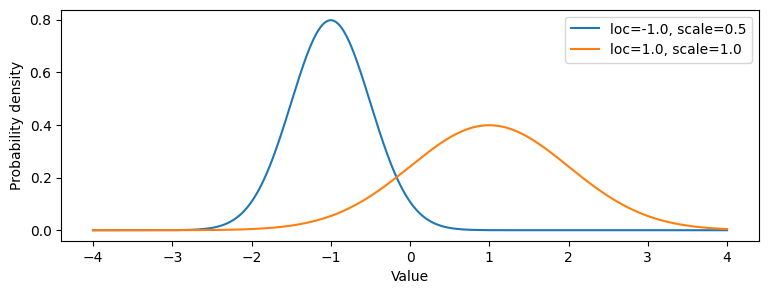

In [ ]:
# Univariate density functions
import torch
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(seed=42)

t = torch.linspace(start=-4, end=4, steps=10000, dtype=torch.float32)
# each column is a vector of densities for one distn
densities = torch.exp(normal.log_prob(value=t[:, None]))

plt.figure(figsize=(9, 3))
sns.lineplot(x=t.numpy(), y=densities[:, 0].numpy(),
    label="loc=%.1f, scale=%.1f"%(
        locs[0].numpy(), scales[0].numpy()
    )
)
sns.lineplot(x=t.numpy(), y=densities[:, 1].numpy(),
    label="loc=%.1f, scale=%.1f"%(
        locs[1].numpy(), scales[1].numpy()
    )
)
plt.ylabel(ylabel='Probability density')
plt.xlabel(xlabel='Value')
plt.legend()
plt.show()

In [ ]:
# Use Independent to convert the batch shape to the event shape
import torch

torch.manual_seed(seed=42)

normal = torch.distributions.Independent(base_distribution=normal,
    reinterpreted_batch_ndims=1)

# Note that dimension from batch_shape has shifted to event_shape
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

Batch shape: torch.Size([])
Event shape: torch.Size([2])


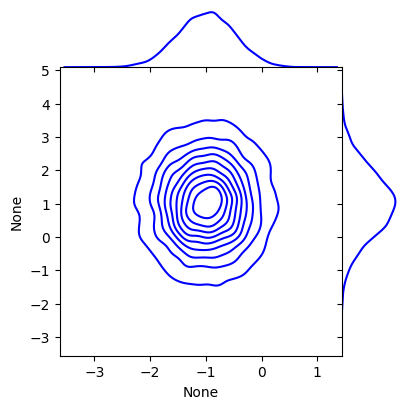

In [ ]:
# Create a plot showing joint density contours and marginal density functions
import matplotlib.pyplot as plt
import seaborn as sns

plt_samples = normal.sample(sample_shape=(10000,)).numpy()
sns.jointplot(x=plt_samples[:, 0], y=plt_samples[:, 1],
    kind='kde', space=0, color='b', height=4)
plt.show()

In [ ]:
# Use MultivariateNormalDiag to create the equivalent distribution
# Note that diagonal covariance matrix => no correlation => independence (for the multivariate normal distribution)
import torch

torch.manual_seed(seed=42)

loc = torch.tensor(data=[-1., 1.])
scale_diag = torch.tensor(data=[0.5, 1.])
sigma = torch.diag_embed(input=scale_diag**2)
scale_tril = torch.linalg.cholesky(input=sigma)
normal = torch.distributions.MultivariateNormal(loc=loc, scale_tril=scale_tril)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

Batch shape: torch.Size([])
Event shape: torch.Size([2])


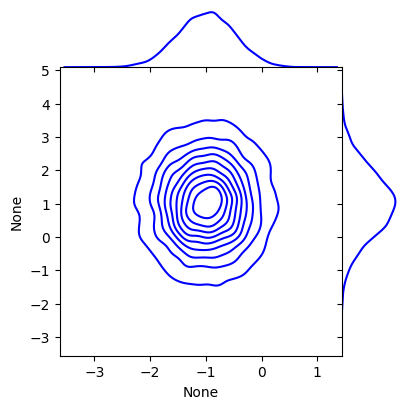

In [ ]:
# Plot the joint density function of bivariate_normal_from_Multivariate
# Refer back to bivariate_normal_from_Independent to show that the plot is the same
# Summarise how Independent has been used
import matplotlib.pyplot as plt
import seaborn as sns

plt_samples = normal.sample(sample_shape=(10000,)).numpy()
sns.jointplot(x=plt_samples[:, 0], y=plt_samples[:, 1],
    kind='kde', space=0, color='b', height=4)
plt.show()

#### Shifting batch dimensions to event dimensions using
`reinterpreted_batch_ndims`

In [ ]:
# Demonstrate use of reinterpreted_batch_ndims
# By default all batch dims except the first are transferred to event dims
import torch

torch.manual_seed(seed=42)

loc = torch.tensor(data=[[-100.], [100.], [0.]])
scale = torch.tensor(data=[[1., 10.], [1., 10.], [1., 1.]])

normal_b3x2_e1 = torch.distributions.Normal(loc=loc, scale=scale)

# Highlight batch_shape
print("Batch shape:", normal_b3x2_e1.batch_shape)
print("Event shape:", normal_b3x2_e1.event_shape)

Batch shape: torch.Size([3, 2])
Event shape: torch.Size([])


In [ ]:
# We now have a batch of 3 bivariate normal distributions,
# each parametrised by a column of our original parameter grid
import torch

torch.manual_seed(seed=42)

normal_b3_e2 = torch.distributions.Independent(base_distribution=normal_b3x2_e1,
    reinterpreted_batch_ndims=1)
print("Batch shape:", normal_b3_e2.batch_shape)
print("Event shape:", normal_b3_e2.event_shape)

Batch shape: torch.Size([3])
Event shape: torch.Size([2])


In [ ]:
# Evaluate log_prob
import torch

torch.manual_seed(seed=42)

value = torch.tensor(data=[[-10., 10.], [-100., 100.], [-1., 1.]])
normal_b3_e2.log_prob(value=value)

tensor([-4.1146e+03, -2.0004e+04, -2.8379e+00])

In [ ]:
# Can reinterpret _all_ batch dimensions as event dimensions
import torch

torch.manual_seed(seed=42)

normal_b1_e3x2 = torch.distributions.Independent(base_distribution=normal_b3x2_e1,
    reinterpreted_batch_ndims=2)
print("Batch shape:", normal_b1_e3x2.batch_shape)
print("Event shape:", normal_b1_e3x2.event_shape)

Batch shape: torch.Size([])
Event shape: torch.Size([3, 2])


In [ ]:
# Take log_probs

normal_b1_e3x2.log_prob(value=value)

tensor(-24121.6172)

#### Using `Independent` to build a Naive Bayes classifier

#### Introduction to `newsgroups` data set

In this tutorial, just load the dataset, fetch train/test splits, probably choose a subset of the data.

Construct the class conditional feature distribution (with Independent, using the Naive Bayes assumption) and sample from it.

We can just use the ML estimates for parameters, in later tutorials we will learn them.

In [ ]:
# Convenience function for retrieving the 20 newsgroups data set

# Usenet was a forerunner to modern internet forums
# Users could post and read articles
# Newsgroup corresponded to a topic
# Example topics in this data set: IBM computer hardware, baseball
# Our objective is to use an article's contents to predict its newsgroup,
# a 20-class classification problem.

# 18000 newsgroups, posts on 20 topics
# Get the train data
from sklearn import datasets

newsgroups_data = datasets.fetch_20newsgroups(
    data_home='data/20_Newsgroup_Data/', subset='train')

In [ ]:
# More information about the data set

print(newsgroups_data['DESCR'])

.. _20newsgroups_dataset:

The 20 newsgroups text dataset
------------------------------

The 20 newsgroups dataset comprises around 18000 newsgroups posts on
20 topics split in two subsets: one for training (or development)
and the other one for testing (or for performance evaluation). The split
between the train and test set is based upon a messages posted before
and after a specific date.

This module contains two loaders. The first one,
:func:`sklearn.datasets.fetch_20newsgroups`,
returns a list of the raw texts that can be fed to text feature
extractors such as :class:`~sklearn.feature_extraction.text.CountVectorizer`
with custom parameters so as to extract feature vectors.
The second one, :func:`sklearn.datasets.fetch_20newsgroups_vectorized`,
returns ready-to-use features, i.e., it is not necessary to use a feature
extractor.

**Data Set Characteristics:**

=================   ==========
Classes                     20
Samples total            18846
Dimensionality               1

In [ ]:
# Example article

print(newsgroups_data['data'][0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [ ]:
# Associated label

newsgroups_data['target'][0]

np.int64(7)

In [ ]:
# Name of label

newsgroups_data['target_names'][7]

'rec.autos'

In [ ]:
# Preprocessing boilerplate
from sklearn import feature_extraction

n_documents = len(newsgroups_data['data'])

# ignore common words, words that appear once
count_vectorizer = feature_extraction.text.CountVectorizer(input='content',
    binary=True, max_df=0.25, min_df=1.01/n_documents)
# input is a list of strings
binary_bag_of_words = count_vectorizer.fit_transform(
    raw_documents=newsgroups_data['data'])

In [ ]:
# Check shape

binary_bag_of_words.shape

(11314, 56365)

In [ ]:
# Check that the fit has been successful

count_vectorizer.inverse_transform(X=binary_bag_of_words[0, :])

[array(['lerxst', 'wam', 'umd', 'where', 'thing', 'car', 'rac3',
        'maryland', 'college', 'park', '15', 'wondering', 'anyone',
        'could', 'enlighten', 'saw', 'day', 'door', 'sports', 'looked',
        'late', '60s', 'early', '70s', 'called', 'bricklin', 'doors',
        'were', 'really', 'small', 'addition', 'front', 'bumper',
        'separate', 'rest', 'body', 'tellme', 'model', 'name', 'engine',
        'specs', 'years', 'production', 'made', 'history', 'whatever',
        'info', 'funky', 'looking', 'please', 'mail', 'thanks', 'il',
        'brought', 'neighborhood'], dtype='<U80')]

In [ ]:
# Dict that will be useful later

inv_vocabulary = {value: key for key, value in count_vectorizer.vocabulary_.items()}

#### A Naive Bayes classifier for `newsgroup`

Each feature vector $x$ is a list of indicators for whether a word appears in the article. $x_i$ is 1 if the $i$th word appears, and 0 otherwise. `inv_vocabulary` matches word indices $i$ to words.

Each label $y$ is a value in $0, 1, \ldots, 19$.

The parts of a naive Bayes classifier for this problem can be summarised as:  


- A probability distribution for the feature vector by class, $p(x|y = j)$ for each $j = 0, 1, \ldots, 19$. These probability distributions are assumed to have independent components: we can factorize the joint probability as a product of marginal probabilities
\begin{equation*}
    p(x|y = j) = \prod_{i=1}^d p(x_i|y = j)
\end{equation*}
These marginal probability distributions are Bernoulli distributions, each of which has a single parameter $\theta_{ji} := p(x_i = 1|y = j)$. This parameter is the probability of observing word $i$ in an article of class $j$.

- We will use the Laplace smoothed maximum likelihood estimate to compute these parameters. Laplace smoothing involves adding small counts to every feature for each class. Else, if a feature did not appear in the training set of a class, but then we observed it in our test data the log probability would be undefined.

- A collection of class prior probabilities $p(y = j)$. These will be set by computing the class base rates in the training set.  


- A function for computing the probability of class membership via Bayes' theorem:  

\begin{equation*}
    p(y = j|x) = \frac{p(x|y = j)p(y = j)}{p(x)}
\end{equation*}

In [ ]:
# Compute the parameter estimates (adjusted fraction of documents in class that contain word)
import numpy as np

n_classes = newsgroups_data['target'].max() + 1
y = newsgroups_data['target']
n_words = binary_bag_of_words.shape[1]

alpha = 1e-6 # parameters for Laplace smoothing

theta = np.zeros(shape=(n_classes, n_words)) # stores parameter values - prob. word given class
for c_k in range(n_classes): # 0, 1, ..., 19
    class_mask = (y == c_k)
    N = class_mask.sum() # number of articles in class
    theta[c_k, :] = (binary_bag_of_words[class_mask, :].sum(axis=0) + alpha)\
        /(N + alpha*2)

theta.shape

(20, 56365)

In [ ]:
# Check whether the most probable word in each class is reasonable

most_probable_word_ix = theta.argmax(axis=1) # most probable word for each class

for j, ix in enumerate(most_probable_word_ix):
    print('Most probable word in class {} is "{}".'.format(
        newsgroups_data['target_names'][j], inv_vocabulary[ix]))

Most probable word in class alt.atheism is "people".
Most probable word in class comp.graphics is "graphics".
Most probable word in class comp.os.ms-windows.misc is "windows".
Most probable word in class comp.sys.ibm.pc.hardware is "thanks".
Most probable word in class comp.sys.mac.hardware is "mac".
Most probable word in class comp.windows.x is "window".
Most probable word in class misc.forsale is "sale".
Most probable word in class rec.autos is "car".
Most probable word in class rec.motorcycles is "dod".
Most probable word in class rec.sport.baseball is "he".
Most probable word in class rec.sport.hockey is "ca".
Most probable word in class sci.crypt is "clipper".
Most probable word in class sci.electronics is "use".
Most probable word in class sci.med is "reply".
Most probable word in class sci.space is "space".
Most probable word in class soc.religion.christian is "god".
Most probable word in class talk.politics.guns is "people".
Most probable word in class talk.politics.mideast is 

In [ ]:
# Define a distribution for each class
import torch

torch.manual_seed(seed=42)

probs = torch.from_numpy(theta)
bernoulli = torch.distributions.Bernoulli(probs=probs)
print("Bernoulli Batch shape:", bernoulli.batch_shape)
print("Bernollie Event shape:", bernoulli.event_shape)

p_x_given_y = torch.distributions.Independent(
    base_distribution=bernoulli, reinterpreted_batch_ndims=1)
print("p_x_given_y Batch shape:", p_x_given_y.batch_shape)
print("p_x_given_y Event shape:", p_x_given_y.event_shape)

Bernoulli Batch shape: torch.Size([20, 56365])
Bernollie Event shape: torch.Size([])
p_x_given_y Batch shape: torch.Size([20])
p_x_given_y Event shape: torch.Size([56365])


In [ ]:
# Take a sample of words from each class

n_samples = 2
samples = p_x_given_y.sample(sample_shape=(n_samples,))
samples.shape

torch.Size([2, 20, 56365])

In [ ]:
# Choose a class

chosen_class = 7
newsgroups_data['target_names'][chosen_class]

'rec.autos'

In [ ]:
# Indicators for words that appear in the sample

class_samples = samples[:, chosen_class, :]
class_samples

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64)

In [ ]:
# Perform inverse transform to test quality of fit

count_vectorizer.inverse_transform(X=class_samples)

[array(['190', '253', '29', '654', '___', 'aardvark', 'accept', 'add',
        'ag', 'against', 'also', 'auto', 'awd', 'basically', 'below',
        'between', 'bicycling', 'both', 'break', 'buick', 'came', 'car',
        'cars', 'chance', 'cheap', 'clint', 'coll', 'committing',
        'comparisons', 'dealer', 'directly', 'doesn', 'doing', 'dr',
        'drew', 'driver', 'drop', 'dunn', 'el', 'end', 'entire', 'fit',
        'ford', 'freon', 'funky', 'gaelic', 'give', 'gold', 'good', 'high',
        'inc', 'lubricants', 'make', 'meet', 'much', 'name', 'net', 'new',
        'off', 'oil', 'onto', 'our', 'over', 'overtake', 'permitted',
        'pointless', 'previous', 'prices', 'provide', 'read', 'ready',
        'real', 'really', 'recently', 'recommendation', 'regarding',
        'robert', 'royal', 'rules', 'says', 'serious', 'she', 'should',
        'smug', 'state', 'still', 'than', 'thanks', 'though', 'thought',
        'time', 'torque', 'using', 'vehicle', 'vehicles', 'warped',
     

***
<a id='sampling_and_log_probs'></a>
## Sampling and log probs

In [ ]:
import torch

torch.manual_seed(seed=42)

rate = torch.tensor(data=[[1., 1.5, 0.8], [0.3, 0.4, 1.8]])
exponential = torch.distributions.Exponential(rate=rate)
print("Batch shape:", exponential.batch_shape)
print("Event shape:", exponential.event_shape)

Batch shape: torch.Size([2, 3])
Event shape: torch.Size([])


In [ ]:
import torch

torch.manual_seed(seed=42)

exponential = torch.distributions.Independent(base_distribution=exponential,
    reinterpreted_batch_ndims=1)
print("Batch shape:", exponential.batch_shape)
print("Event shape:", exponential.event_shape)

exponential.sample(sample_shape=(2,))

Batch shape: torch.Size([2])
Event shape: torch.Size([3])


tensor([[[0.0599, 0.0433, 0.1649],
         [0.1800, 1.8673, 0.3599]],

        [[3.1063, 1.7611, 0.1091],
         [0.4743, 0.4271, 0.2614]]])

In [ ]:
import torch

torch.manual_seed(seed=42)

rate = torch.tensor(data=[
    [[[1., 1.5, 0.8], [0.3, 0.4, 1.8]]],
    [[[0.2, 0.4, 1.4], [0.4, 1.1, 0.9]]]
])
exponential = torch.distributions.Exponential(rate=rate)
print("Exponential Batch shape:", exponential.batch_shape)
print("Exponential Event shape:", exponential.event_shape)

exponential = torch.distributions.Independent(base_distribution=exponential,
    reinterpreted_batch_ndims=2)
print("Independent Batch shape:", exponential.batch_shape)
print("Independent Event shape:", exponential.event_shape)

exponential.sample(sample_shape=(1, 2))

Exponential Batch shape: torch.Size([2, 1, 2, 3])
Exponential Event shape: torch.Size([])
Independent Batch shape: torch.Size([2, 1])
Independent Event shape: torch.Size([2, 3])


tensor([[[[[[ 0.0599,  0.0433,  0.1649],
            [ 0.1800,  1.8673,  0.3599]]],


          [[[15.5317,  6.6040,  0.0623],
            [ 0.3558,  0.1553,  0.5229]]]],



         [[[[ 1.8485,  1.3627,  0.5926],
            [ 3.1596,  0.2306,  0.6711]]],


          [[[ 4.8829,  1.4374,  0.0555],
            [ 2.8755,  0.3403,  0.4108]]]]]])

In [ ]:
import torch

torch.manual_seed(seed=42)

value = torch.tensor(data=0.5)
exponential.log_prob(value=value)

tensor([[-4.2502],
        [-5.3156]])

In [ ]:
import torch

torch.manual_seed(seed=42)

value = torch.tensor(data=[[0.3, 0.5, 0.8]])
exponential.log_prob(value=value)

tensor([[-4.7702],
        [-5.8856]])

In [ ]:
import torch

torch.manual_seed(seed=42)

value = torch.rand(2, 1, 1, 2, 1)
exponential.log_prob(value=value)

tensor([[[-6.5492],
         [-7.0761]],

        [[-5.0119],
         [-6.1837]]])

In [ ]:
# Make Multivariate Distribution
import torch

torch.manual_seed(seed=42)

loc = torch.tensor(data=[[0.5, 1.], [0.1, 0.], [0., 0.2]])
scale_diag = torch.tensor(data=[[2., 3.], [1., 3.], [4., 4.]])
sigma = torch.diag_embed(input=scale_diag**2)
scale_tril = torch.linalg.cholesky(input=sigma)
normal = torch.distributions.MultivariateNormal(loc=loc, scale_tril=scale_tril)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

Batch shape: torch.Size([3])
Event shape: torch.Size([2])


In [ ]:
# Sample

normal.sample(sample_shape=(2,))

tensor([[[ 1.1734,  1.3864],
         [ 0.3345,  0.6910],
         [-4.4914, -0.5453]],

        [[ 4.9164, -0.9140],
         [ 0.5617,  0.8021],
         [ 2.1396,  3.4374]]])

In [ ]:
# Multivariate Normal batched Distribution
# We are broadcasting batch shapes of `loc` and `scal_diag`
# against each other
import torch

torch.manual_seed(seed=42)

loc = torch.tensor(data=[
    [[0.3, 1.5, 1.], [0.2, 0.4, 2.8]],
    [[2., 2.3, 8.], [1.4, 1., 1.3]]
])
scale_diag = torch.tensor(data=[0.4, 1, 0.7])
sigma = torch.diag_embed(input=scale_diag**2)
scale_tril = torch.linalg.cholesky(input=sigma)
normal = torch.distributions.MultivariateNormal(loc=loc, scale_tril=scale_tril)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

Batch shape: torch.Size([2, 2])
Event shape: torch.Size([3])


In [ ]:
# Use independent to move part of the batch shape
import torch

torch.manual_seed(seed=42)

normal = torch.distributions.Independent(base_distribution=normal,
    reinterpreted_batch_ndims=1)
print("Batch shape:", normal.batch_shape)
print("Event shape:", normal.event_shape)

Batch shape: torch.Size([2])
Event shape: torch.Size([2, 3])


In [ ]:
# Draw some samples

normal.sample(sample_shape=(2,))

tensor([[[[ 1.0708,  2.9873,  1.6305],
          [-0.6422,  1.0784,  1.9358]],

         [[ 1.9828,  0.6953,  8.2491],
          [ 1.1254,  0.5066,  1.4690]]],


        [[[-0.1444,  1.5915, -0.6218],
          [ 0.1133,  0.0903,  2.5230]],

         [[ 2.3214,  1.6784,  7.5856],
          [ 1.3748,  0.1714,  1.5316]]]])

In [ ]:
# `[B, E]` shaped input
import torch

torch.manual_seed(seed=42)

value = torch.rand(2, 2, 3)
normal.log_prob(value=value)

tensor([-11.3234, -69.9769])

In [ ]:
# `[E]` shaped input (broadcasting over batch size)
import torch

torch.manual_seed(seed=42)

value = torch.rand(2, 3)
normal.log_prob(value=value)

tensor([-11.3234, -68.3272])

In [ ]:
#`[S, B, E]` shaped input (broadcasting over samples)
import torch

torch.manual_seed(seed=42)

value = torch.rand(3, 2, 2, 3)
normal.log_prob(value=value)

tensor([[-11.3234, -69.9769],
        [ -9.8228, -78.0772],
        [-12.2384, -63.0694]])

In [ ]:
# `[S, b, e]` shaped input, where [b, e] is broadcastable over [B, E]
import torch

torch.manual_seed(seed=42)

value = torch.rand(3, 1, 2, 3)
normal.log_prob(value=value)

tensor([[-11.3234, -68.3272],
        [ -8.3511, -69.9769],
        [ -9.8228, -65.7181]])

#### Naive Bayes example

Lets now use what we have learned and continue the Naive Bayes classifier we were building last tutorial.

In [ ]:
# Making a function get_data which:
#   1) Fetches the 20 newsgroup dataset
#   2) Performs a word count on the articles and binarizes the result
#   3) Returns the data as a numpy matrix with the labels
from sklearn import datasets
from sklearn import feature_extraction

def get_data(categories):
    newsgroups_train_data = datasets.fetch_20newsgroups(
        data_home='data/20_Newsgroup_Data/', subset='train', categories=categories)
    newsgroups_test_data = datasets.fetch_20newsgroups(
        data_home='data/20_Newsgroup_Data/', subset='test', categories=categories)

    n_documents = len(newsgroups_train_data['data'])
    count_vectorizer = feature_extraction.text.CountVectorizer(input='content',
        binary=True, max_df=0.25, min_df=1.01/n_documents)

    train_binary_bag_of_words = count_vectorizer.fit_transform(
        raw_documents=newsgroups_train_data['data'])
    test_binary_bag_of_words = count_vectorizer.transform(
        raw_documents=newsgroups_test_data['data'])

    return (train_binary_bag_of_words.todense(),
            newsgroups_train_data['target']), \
        (test_binary_bag_of_words.todense(),
            newsgroups_test_data['target'])

In [ ]:
# Defining a function to conduct Laplace smoothing. This adds a base
# level of probability for a given feature to occur in every class.
import numpy as np
np.random.seed(seed=42)

def laplace_smoothing(labels, binary_data, n_classes):
    # Compute the parameter estimates (adjusted fraction of documents
    # in class that contain word)
    n_words = binary_data.shape[1]
    alpha = 1 # parameters for Laplace smoothing
    # stores parameter values - prob. word given class
    theta = np.zeros(shape=(n_classes, n_words))
    for c_k in range(n_classes): # 0, 1, ..., 19
        class_mask = (labels == c_k)
        N = class_mask.sum() # number of articles in class
        theta[c_k, :] = (binary_data[class_mask, :].sum(axis=0) + alpha)\
            /(N + alpha*2)

    return theta

In [ ]:
# Getting a subset of the 20 newsgroup dataset

categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space']

(train_data, train_labels), (test_data, test_labels) = get_data(
    categories=categories)
smoothed_counts = laplace_smoothing(labels=train_labels, binary_data=train_data,
    n_classes=len(categories))
smoothed_counts.shape

(4, 17495)

To now make our NB classifier we need to build three functions:
* Compute the class priors
* Build our class conditional distributions
* Put it all together and classify our data

In [ ]:
# Function which computes the prior probability of every class
# based on frequency of occurence in the dataset
import numpy as np
np.random.seed(seed=42)

def class_priors(n_classes, labels):
    counts = np.zeros(shape=n_classes)
    for c_k in range(n_classes):
        counts[c_k] = np.sum(np.where(labels==c_k, 1, 0))
    priors = counts / np.sum(counts)
    print('The class priors are {}'.format(priors))

    return priors

In [ ]:
# Run the function

priors = class_priors(n_classes=len(categories), labels=train_labels)

The class priors are [0.2359882  0.28711898 0.29154376 0.18534907]


In [ ]:
# Now we will do a function that given the feature occurence counts
# returns a Bernoulli distribution of batch_shape=number of classes
# and event_shape=number of features.
import torch
torch.manual_seed(seed=42)

def make_distribution(probs):
    probs = torch.from_numpy(probs)
    bernoulli = torch.distributions.Bernoulli(probs=probs)
    dist = tfp.distributions.Independent(
        distribution=batch_of_bernoullis, reinterpreted_batch_ndims=1)

    return dist

tf_dist = make_distribution(probs = smoothed_counts)
tf_dist

<tfp.distributions.Independent 'IndependentBernoulli' batch_shape=[4] event_shape=[17495] dtype=int32>

In [ ]:
# The final function predict_sample which given the distribution,
#  a test sample, and the class priors:
#   1) Computes the class conditional probabilities given the sample
#   2) Forms the joint likelihood
#   3) Normalises the joint likelihood and returns the log prob
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

def predict_sample(dist, sample, priors):
    cond_probs = dist.log_prob(value=sample)
    priors = tf.math.log(x=tf.convert_to_tensor(
        value=priors, dtype=tf.float32))
    joint_likelihood = tf.math.add(x=priors, y=cond_probs)
    norm_factor = tf.math.reduce_logsumexp(
        input_tensor=joint_likelihood, axis=-1, keepdims=True)
    log_prob = joint_likelihood - norm_factor

    return log_prob

#### Computing log_probs

In [ ]:
# Predicting one example from our test data

log_probs = predict_sample(dist=tf_dist,
    sample=test_data[0], priors=priors)
log_probs

<tf.Tensor: shape=(4,), dtype=float32, numpy=
array([-6.1736267e+01, -1.5258789e-05, -1.1619873e+01, -6.3327835e+01],
      dtype=float32)>

In [ ]:
# Loop over our test data and classify.
import tensorflow as tf
import numpy as np
from sklearn import metrics
tf.keras.utils.set_random_seed(seed=42)

probabilities = []
for sample, label in zip(test_data, test_labels):
    probabilities.append(tf.math.exp(x=predict_sample(
        dist=tf_dist, sample=sample, priors=priors)))

probabilities = np.asarray(a=probabilities)
predicted_classes = np.argmax(a=probabilities, axis=-1)
print('f1:', metrics.f1_score(y_true=test_labels,
    y_pred=predicted_classes, average='macro'))

f1: 0.7848499112849505


In [ ]:
# Make a Bernoulli Naive Bayes classifier using
# sklearn with the same level of alpha smoothing.
from sklearn import naive_bayes, metrics

clf = naive_bayes.BernoulliNB(alpha=1.)
clf.fit(X=np.asarray(a=train_data), y=train_labels)
pred = clf.predict(X=np.asarray(a=test_data))
print('f1 from sklean', metrics.f1_score(
    y_true=test_labels, y_pred=pred, average='macro'))

f1 from sklean 0.7848499112849505


***
<a id='trainable_distributions'></a>
## Trainable Distributions

In [ ]:
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

normal = tfp.distributions.Normal(loc=
    tf.Variable(initial_value=0., name='loc'), scale=1.)
print(normal.trainable_variables)

def nll(x):
    return -tf.math.reduce_mean(input_tensor=
        normal.log_prob(value=x))

@tf.function
def get_loss_and_grads(x):
    with tf.GradientTape() as tape:
        tape.watch(tensor=normal.trainable_variables)
        loss = nll(x=x)
    grads = tape.gradient(target=loss,
        sources=normal.trainable_variables)

    return loss, grads

optimizer = tf.keras.optimizers.SGD(learning_rate=0.05)

x = tf.random.normal(shape=(100,), mean=1.)
for _ in range(10):
    loss, grads = get_loss_and_grads(x=x)
    optimizer.apply_gradients(grads_and_vars=zip(
        grads, normal.trainable_variables))
    print("loss=%.4f, loc=%.4f"%(loss.numpy(), normal.loc.numpy()))

(<tf.Variable 'loc:0' shape=() dtype=float32, numpy=0.0>,)
loss=1.7617, loc=0.0428
loss=1.7259, loc=0.0835
loss=1.6936, loc=0.1222
loss=1.6644, loc=0.1589
loss=1.6381, loc=0.1938
loss=1.6144, loc=0.2270
loss=1.5930, loc=0.2585
loss=1.5736, loc=0.2884
loss=1.5562, loc=0.3168
loss=1.5404, loc=0.3438


In [ ]:
# Define an exponential distribution
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

exponential = tfp.distributions.Exponential(rate=0.3, name='exp')

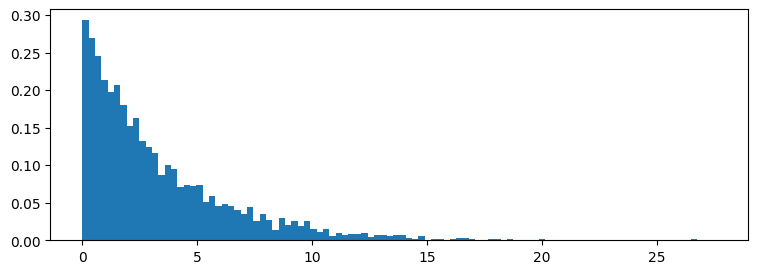

In [ ]:
# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 3))
plt.hist(x=exponential.sample(sample_shape=5000),
    bins=100, density=True)
plt.show()

In [ ]:
# Define an exponential distribution with a trainable rate parameter
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

exp_train = tfp.distributions.Exponential(name='exp_train',
    rate=tf.Variable(initial_value=1., name='rate'))
exp_train.trainable_variables

(<tf.Variable 'rate:0' shape=() dtype=float32, numpy=1.0>,)

In [ ]:
# Define the negative log likelihood
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

def nll(x_train, distribution):
    return -tf.math.reduce_mean(input_tensor=
        distribution.log_prob(value=x_train))

In [ ]:
# Define a function to compute the loss and gradients
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

@tf.function
def get_loss_and_grads(x_train, distribution):
    with tf.GradientTape() as tape:
        tape.watch(tensor=distribution.trainable_variables)
        loss = nll(x_train=x_train, distribution=distribution)
        grads = tape.gradient(target=loss,
            sources=distribution.trainable_variables)

    return loss, grads

In [ ]:
# Optimize
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

def exponential_dist_optimisation(data, distribution):

    # Keep results for plotting
    train_loss_results = []
    train_rate_results = []

    optimizer = tf.keras.optimizers.SGD(learning_rate=0.05)

    num_steps = 10
    for i in range(num_steps):
        loss, grads = get_loss_and_grads(x_train=data,
            distribution=distribution)
        optimizer.apply_gradients(grads_and_vars=zip(
            grads, distribution.trainable_variables))

        rate_value = distribution.rate.value()
        train_loss_results.append(loss)
        train_rate_results.append(rate_value)

        print("Step %2d: Loss: %.3f: Rate: %.3f"%(i, loss, rate_value))

    return train_loss_results, train_rate_results

In [ ]:
# Get some data and train

sampled_data = exponential.sample(sample_shape=5000)
train_loss_results, train_rate_results = exponential_dist_optimisation(
    data=sampled_data, distribution=exp_train)

Step  0: Loss: 3.308: Rate: 0.885
Step  1: Loss: 3.049: Rate: 0.776
Step  2: Loss: 2.820: Rate: 0.675
Step  3: Loss: 2.625: Rate: 0.584
Step  4: Loss: 2.469: Rate: 0.504
Step  5: Loss: 2.352: Rate: 0.438
Step  6: Loss: 2.274: Rate: 0.387
Step  7: Loss: 2.229: Rate: 0.351
Step  8: Loss: 2.208: Rate: 0.328
Step  9: Loss: 2.200: Rate: 0.315


In [ ]:
# Predicted value for the rate parameter

pred_value = exp_train.rate.numpy()
exact_value = exponential.rate.numpy()

print("Exact rate:", exact_value)
print("Pred rate:", pred_value)

Exact rate: 0.3
Pred rate: 0.31494382


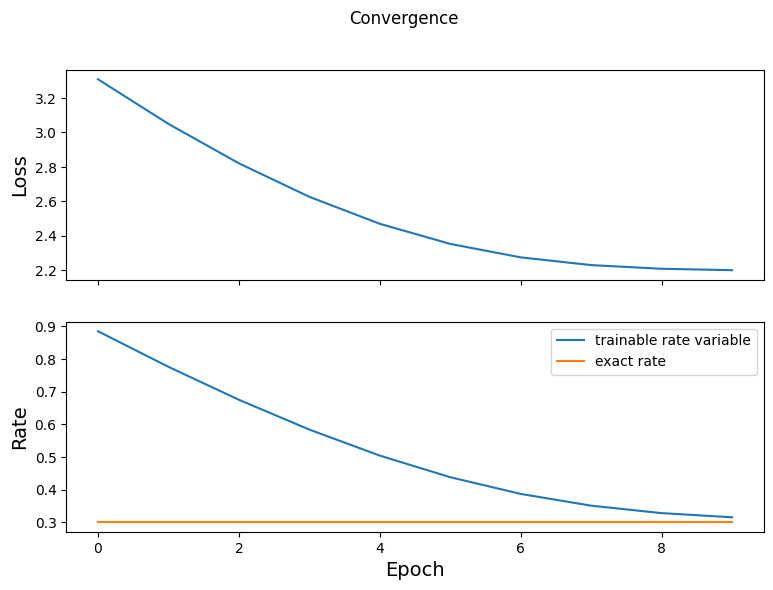

In [ ]:
# Plot to see the convergence of the estimated and true parameters
import tensorflow as tf
import matplotlib.pyplot as plt
tf.keras.utils.set_random_seed(seed=42)

tensor_exact_value = tf.constant(value=exact_value,
    shape=[len(train_rate_results)])

fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(9, 6))
fig.suptitle(t='Convergence')

axes[0].set_ylabel(ylabel="Loss", fontsize=14)
axes[0].plot(train_loss_results)

axes[1].set_ylabel(ylabel="Rate", fontsize=14)
axes[1].set_xlabel(xlabel="Epoch", fontsize=14)
axes[1].plot(train_rate_results, label='trainable rate variable')
axes[1].plot(tensor_exact_value, label='exact rate')
axes[1].legend()
plt.show()

In [ ]:
# Making a function get_data which:
#   1) Fetches the 20 newsgroup dataset
#   2) Performs a word count on the articles and binarizes the result
#   3) Returns the data as a numpy matrix with the labels

from sklearn import datasets
from sklearn.feature_extraction import text

def get_data(categories):

    newsgroups_train_data = datasets.fetch_20newsgroups(
        data_home='20_Newsgroup_Data/', subset='train',
        categories=categories)
    newsgroups_test_data = datasets.fetch_20newsgroups(
        data_home='20_Newsgroup_Data/', subset='test',
        categories=categories)

    n_documents = len(newsgroups_train_data['data'])
    count_vectorizer = text.CountVectorizer(input='content',
        binary=True, max_df=0.25, min_df=1.01/n_documents)
    train_binary_bag_of_words = count_vectorizer.fit_transform(
        raw_documents=newsgroups_train_data['data'])
    test_binary_bag_of_words = count_vectorizer.transform(
        raw_documents=newsgroups_test_data['data'])

    return (train_binary_bag_of_words.todense(),
            newsgroups_train_data['target']), \
        (test_binary_bag_of_words.todense(),
             newsgroups_test_data['target'])

In [ ]:
# Defining a function to conduct laplace smoothing. This adds a base
# level of probability for a given feature to occur in every class.
import numpy as np

def laplace_smoothing(labels, binary_data, n_classes):
    # Compute the parameter estimates (adjusted fraction of documents
    # in class that contain word)
    n_words = binary_data.shape[1]
    alpha = 1 # parameters for Laplace smoothing
    theta = np.zeros(shape=(n_classes, n_words)) # stores parameter values - prob. word given class
    for c_k in range(n_classes): # 0, 1, ..., 19
        class_mask = (labels == c_k)
        N = class_mask.sum() # number of articles in class
        theta[c_k, :] = (binary_data[class_mask, :].sum(axis=0)
            + alpha)/(N + alpha*2)

    return theta

In [ ]:
# Now we will do a function that given the feature occurence counts
# returns a Bernoulli distribution of batch_shape=number of classes
# and event_shape=number of features.
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

def make_distributions(probs):
    # shape (n_classes, n_words)
    batch_of_bernoullis = tfp.distributions.Bernoulli(probs=probs)
    dist = tfp.distributions.Independent(
        distribution=batch_of_bernoullis,
        reinterpreted_batch_ndims=1)

    return dist

In [ ]:
# Function which computes the prior probability of every class
# based on frequency of occurence in the dataset
import numpy as np

def class_priors(n_classes, labels):
    counts = np.zeros(shape=n_classes)
    for c_k in range(n_classes):
        counts[c_k] = np.sum(a=np.where(labels==c_k, 1, 0))
    priors = counts / np.sum(a=counts)
    print('The class priors are {}'.format(priors))

    return priors

In [ ]:
# The final function predict_sample which given the distribution,
# a test sample, and the class priors:
#   1) Computes the class conditional probabilities given the sample
#   2) Forms the joint likelihood
#   3) Normalises the joint likelihood and returns the log prob
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

def predict_sample(dist, sample, priors):
    cond_probs = dist.log_prob(value=sample)
    priors = tf.math.log(x=tf.convert_to_tensor(
        value=priors, dtype=tf.float32))
    joint_likelihood = tf.math.add(x=priors, y=cond_probs)
    norm_factor = tf.math.reduce_logsumexp(
        input_tensor=joint_likelihood, axis=-1, keepdims=True)
    log_prob = joint_likelihood - norm_factor

    return log_prob

In [ ]:
# Define the negative log likelihood
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

def nll(x_train, distribution):
    return -tf.math.reduce_mean(input_tensor=
        distribution.log_prob(value=x_train))

In [ ]:
# Define a function to compute the loss and gradients
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

@tf.function
def get_loss_and_grads(x_train, distribution):
    with tf.GradientTape() as tape:
        tape.watch(tensor=distribution.trainable_variables)
        loss = nll(x_train=x_train, distribution=distribution)
        grads = tape.gradient(target=loss,
            sources=distribution.trainable_variables)

    return loss, grads

In [ ]:
# Now we learn the distribution using gradient tape
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

def make_distribution_withGT(data, labels, nb_classes):

    class_data = []
    train_vars = []
    distributions = []
    for c in range(nb_classes):
        train_vars.append(tf.Variable(
            initial_value=np.random.uniform(
                low=0.01, high=0.1, size=data.shape[-1]),
            dtype=tf.float32))
        distributions.append(tfp.distributions.Bernoulli(
            probs=train_vars[c]))
        class_mask = (labels == c)
        class_data.append(data[class_mask, :])

    for c_num in range(0, nb_classes):
        optimizer = tf.keras.optimizers.Adam()
        print('\n%-------------------%')
        print('Class ', c_num)
        print('%-------------------%')

        for i in range(0, 100):
            loss, grads = get_loss_and_grads(
                x_train=class_data[c_num],
                distribution=distributions[c_num])
            if (i%10==0):
                print("iter: {} loss: {}".format(i, loss))
            optimizer.apply_gradients(grads_and_vars=zip(grads,
                distributions[c_num].trainable_variables))
            eta = 1e-3
            clipped_probs = tf.clip_by_value(
                t=distributions[c_num].trainable_variables,
                clip_value_min=eta, clip_value_max=1)
            train_vars[c_num] = tf.squeeze(input=clipped_probs)

    dist = tfp.distributions.Bernoulli(probs=train_vars)
    dist = tfp.distributions.Independent(
        distribution=dist, reinterpreted_batch_ndims=1)

    return dist

In [ ]:
# Make the same Naive Bayes classifier we did last tutorial

categories = ['alt.atheism', 'talk.religion.misc',
    'comp.graphics', 'sci.space']

(train_data, train_labels), (test_data, test_labels) = get_data(
    categories=categories)

smoothed_counts = laplace_smoothing(labels=train_labels,
    binary_data=train_data, n_classes=len(categories))

priors = class_priors(n_classes=len(categories), labels=train_labels)
tf_dist = make_distributions(probs=smoothed_counts)
tf_dist

The class priors are [0.2359882  0.28711898 0.29154376 0.18534907]


<tfp.distributions.Independent 'IndependentBernoulli' batch_shape=[4] event_shape=[17495] dtype=int32>

In [ ]:
# Now train the distributions with gradient tape

GT_dist = make_distribution_withGT(data=train_data,
    labels=train_labels, nb_classes=4)
GT_dist


%-------------------%
Class  0
%-------------------%
iter: 0 loss: 0.07835053652524948
iter: 10 loss: 0.06897091120481491
iter: 20 loss: 0.06023702025413513
iter: 30 loss: 0.05216425284743309
iter: 40 loss: 0.04470314458012581
iter: 50 loss: 0.03781279921531677
iter: 60 loss: 0.03143986314535141
iter: 70 loss: 0.025541773065924644
iter: 80 loss: 0.02007882110774517
iter: 90 loss: 0.015002498403191566

%-------------------%
Class  1
%-------------------%
iter: 0 loss: 0.07166072726249695
iter: 10 loss: 0.06230592727661133
iter: 20 loss: 0.05350322648882866
iter: 30 loss: 0.045321572571992874
iter: 40 loss: 0.03773637115955353
iter: 50 loss: 0.030704064294695854
iter: 60 loss: 0.02419220097362995
iter: 70 loss: 0.018184632062911987
iter: 80 loss: 0.01265514362603426
iter: 90 loss: 0.007545542903244495

%-------------------%
Class  2
%-------------------%
iter: 0 loss: 0.07816188037395477
iter: 10 loss: 0.06908668577671051
iter: 20 loss: 0.0607297345995903
iter: 30 loss: 0.05311099439859

<tfp.distributions.Independent 'IndependentBernoulli' batch_shape=[4] event_shape=[17495] dtype=int32>

In [ ]:
# Compare the two results
import numpy as np
from sklearn import metrics

for dist in [GT_dist, tf_dist]:
    probabilities = []
    for sample, label in zip(test_data, test_labels):
        probabilities.append(predict_sample(
            dist=dist, sample=sample, priors=priors))

    probabilities = np.asarray(a=probabilities)
    predicted_classes = np.argmax(a=probabilities, axis=-1)
    print('f1 ', metrics.f1_score(y_true=test_labels,
        y_pred=predicted_classes, average='macro'))

f1  0.834607151100081
f1  0.7848499112849505
